In [1]:
using Revise
using ViscousStreaming
using ImmersedLayers
using Plots

[ Info: Precompiling ViscousStreaming [47fb7046-13b0-40db-b6a6-74fa44cf0959] (cache misses: include_dependency fsize change (2))


set up exact solution

In [2]:
Re = 40
ϵ = 0.1
p = ViscousStreaming.StreamingParams(ϵ,Re)

Streaming flow parameters with Re = 40.0, ϵ = 0.1


inertial frame

In [3]:
sol_iner = ViscousStreaming.StreamingAnalytical(p, InertialFrame)

Maximum residual on W₁ = 5.684341886080802e-14
BC residual on Ψ₁(1) = 1.1443916996305594e-16
BC residual on dΨ₁(1) = 2.2887833992611187e-16
Maximum residual on Ws₂ = 3.979039320256561e-13
BC residual on Ψs₂(1) = 3.552713678800501e-15
BC residual on dΨs₂(1) = 2.6645352591003757e-15
Verifying second-order oscillatory solution...
Maximum residual on W₂ = 1.67181510390182e-12
BC residual on Ψ₂(1) = 2.8609792490763984e-17
BC residual on dΨ₂(1) = 2.220446049250313e-15


Analytical streaming flow solution for
single cylinder with Re = 40.0, ϵ = 0.1


cylinder frame

In [4]:
sol_cyl = ViscousStreaming.StreamingAnalytical(p, CylinderFrame)

Maximum residual on W₁ = 5.684341886080802e-14
BC residual on Ψ₁(1) = 1.1443916996305594e-16
BC residual on dΨ₁(1) = 5.551115123125783e-17
Maximum residual on Ws₂ = 2.8883562208648073e-12
BC residual on Ψs₂(1) = 1.790180836524724e-15
BC residual on dΨs₂(1) = 4.440892098500626e-16
Verifying second-order oscillatory solution...
Maximum residual on W₂ = 1.2726453165463516e-12
BC residual on Ψ₂(1) = 6.2546344413855015e-18
BC residual on dΨ₂(1) = 5.721958498152797e-17


Analytical streaming flow solution for
single cylinder with Re = 40.0, ϵ = 0.1


set up plots

In [7]:
spacing = 1.4
Δx = 0.04
Lx = 5.98*2
xlim = (-Lx/2,Lx/2)
ylim = (-Lx/2,Lx/2)
g = PhysicalGrid(xlim,ylim,Δx)
Δs = spacing*cellsize(g)
body = Circle(1.0, Δs)
cache = SurfaceVectorCache(body, g)

Surface cache with scaling of type GridScaling
  112 point data of type VectorData{112, Float64, Vector{Float64}}
  Grid data of type Edges{Primal, 308, 308, Float64, Vector{Float64}}


initialize flow variables

In [16]:
s1_iner = zeros_gridcurl(cache);
s2_iner = similar(s1_iner);
s2s_iner = similar(s1_iner);
s1_cyl = similar(s1_iner);
s2_cyl = similar(s1_iner);
s2s_cyl = similar(s1_iner);
w1_iner = similar(s1_iner);
w1_cyl = similar(s1_iner);
w2s_iner = similar(s1_iner);
w2s_cyl = similar(s1_iner);

compute flow variables

In [9]:
x_coord = x_gridcurl(cache)[:,1]
y_coord = y_gridcurl(cache)[1,:]
s1_iner .= [streamfunction(x, y, 0.0, sol_iner.s1) for x in x_coord, y in y_coord];
s2_iner .= [streamfunction(x, y, 0.0, sol_iner.s2) for x in x_coord, y in y_coord];
s2s_iner .= [streamfunction(x, y, sol_iner.s2s) for x in x_coord, y in y_coord];
s1_cyl .= [streamfunction(x, y, 0.0, sol_cyl.s1) for x in x_coord, y in y_coord];
s2_cyl .= [streamfunction(x, y, 0.0, sol_cyl.s2) for x in x_coord, y in y_coord];
s2s_cyl .= [streamfunction(x, y, sol_cyl.s2s) for x in x_coord, y in y_coord];

In [10]:
w1_iner .= [vorticity(x, y, 0.0, sol_iner.s1) for x in x_coord, y in y_coord];
w1_cyl .= [vorticity(x, y, 0.0, sol_cyl.s1) for x in x_coord, y in y_coord];

In [17]:
w2s_iner .= [vorticity(x, y, sol_iner.s2s) for x in x_coord, y in y_coord];
w2s_cyl .= [vorticity(x, y, sol_cyl.s2s) for x in x_coord, y in y_coord];

plot

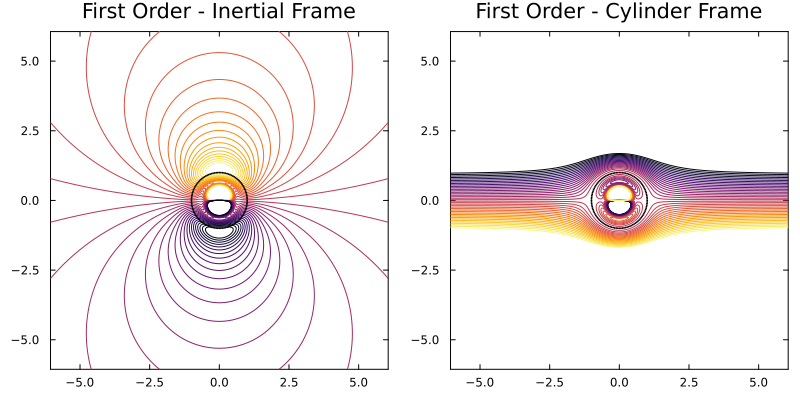

In [11]:
lim = 1
p1 = plot(s1_iner, cache, levels=range(-lim, lim, length=40), clim=(-lim, lim))
p2 = plot(s1_cyl, cache, levels=range(-lim, lim, length=40), clim=(-lim, lim))
plot(p1, p2, layout=(1,2), size=(800,400), title=["First Order - Inertial Frame" "First Order - Cylinder Frame"])

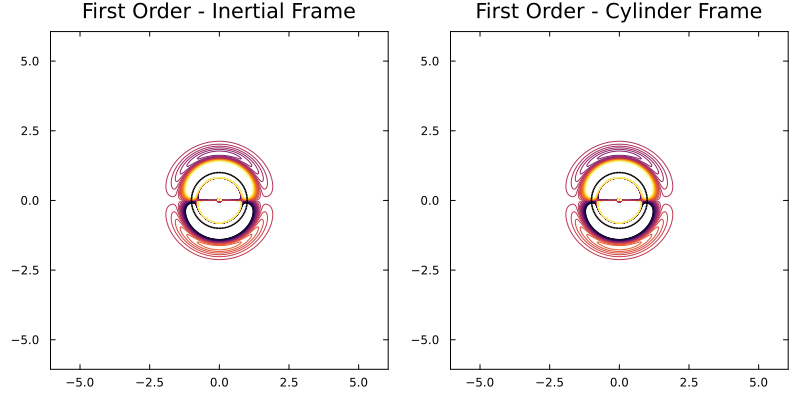

In [12]:
lim = 1
p1 = plot(w1_iner, cache, levels=range(-lim, lim, length=40), clim=(-lim, lim))
p2 = plot(w1_cyl, cache, levels=range(-lim, lim, length=40), clim=(-lim, lim))
plot(p1, p2, layout=(1,2), size=(800,400), title=["First Order - Inertial Frame" "First Order - Cylinder Frame"])

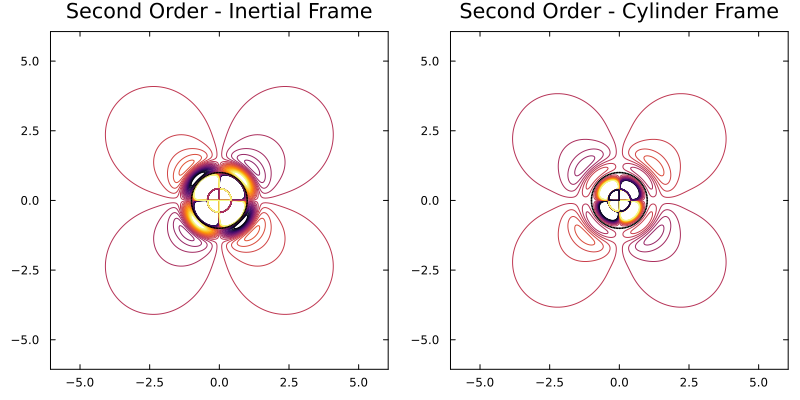

In [13]:
lim = 0.1
p1 = plot(s2_iner, cache, levels=range(-lim, lim, length=40), clim=(-lim, lim))
p2 = plot(s2_cyl, cache, levels=range(-lim, lim, length=40), clim=(-lim, lim))
plot(p1, p2, layout=(1,2), size=(800,400), title=["Second Order - Inertial Frame" "Second Order - Cylinder Frame"])

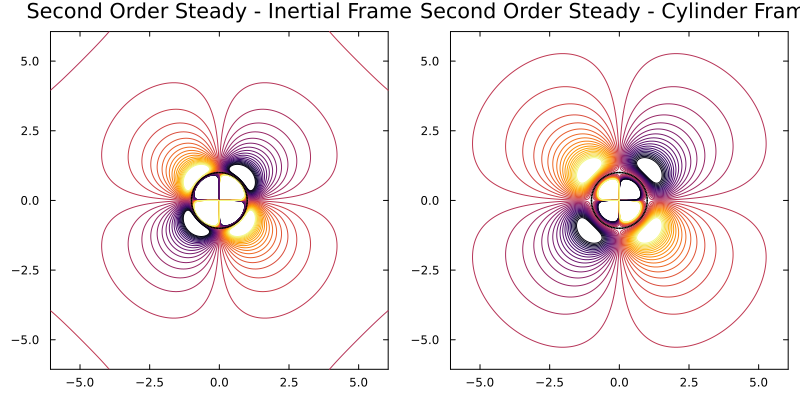

In [14]:
lim1 = 0.1
lim2 = 0.1
p1 = plot(s2s_iner, cache, levels=range(-lim1, lim1, length=40), clim=(-lim1, lim1))
p2 = plot(s2s_cyl, cache, levels=range(-lim2, lim2, length=40), clim=(-lim2, lim2))
plot(p1, p2, layout=(1,2), size=(800,400), title=["Second Order Steady - Inertial Frame" "Second Order Steady - Cylinder Frame"])

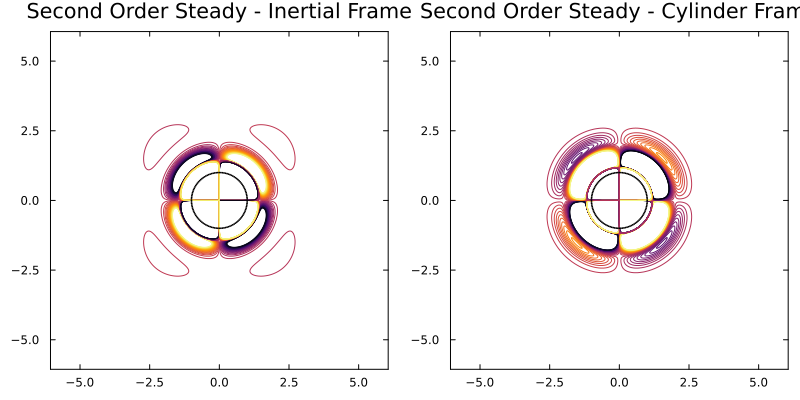

In [18]:
lim1 = 0.1
lim2 = 0.1
p1 = plot(w2s_iner, cache, levels=range(-lim1, lim1, length=40), clim=(-lim1, lim1))
p2 = plot(w2s_cyl, cache, levels=range(-lim2, lim2, length=40), clim=(-lim2, lim2))
plot(p1, p2, layout=(1,2), size=(800,400), title=["Second Order Steady - Inertial Frame" "Second Order Steady - Cylinder Frame"])